In [44]:
import matplotlib.pyplot as plt
import astricaltools as at
import numpy as np
import pandas as pd
import scipy.stats as sc
from astropy import stats
import astropy.units as u
from astropy.io import fits
from astropy.table import vstack, Table
from astropy.time import Time
from astropy.timeseries import TimeSeries
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, Angle

In [45]:
file_numbers = range(1, 10)  # da 001 a 009
base_path = "astri_{:03d}_43_009_00002_R_200101_001_0201_SEB.lv0"  # pattern del nome file

dfs = []  # lista per accumulare i DataFrame
print("\n")
for i in file_numbers:
    filename = base_path.format(i)
    print(f"{filename}")

    with at.io.fits.AstriFits(filename) as hdul:
        data = hdul[1].data

        # Conversione dei campi
        time_ns = data["TIME_NS"].byteswap().newbyteorder().astype(np.int64)
        time_s  = data["TIME_S"].byteswap().newbyteorder().astype(np.int64)
        event   = data["EVTNUM"].byteswap().newbyteorder().astype(np.int64)
        mcrun   = data["MCRUNNUM"].byteswap().newbyteorder().astype(np.int64)
        ntel= data["NTRIGTEL"]
        time_abs = time_s * 10**9 + time_ns  # tempo assoluto in ns
        hg, lg, ttp = hdul.get_data('events', ['hi', 'lo', 'ttp'])
        time_abs = time_s * 10**9 + time_ns  # tempo assoluto in ns
            #creo il dataframe
        df = pd.DataFrame({
                "TIME_NS": time_ns,
                "TIME_S": time_s,
                "TIME_ABS": time_abs,
                "EVENT": event,
                "MCRUN": mcrun,
                "TEL_ID": i,
                "num_tel": ntel,
                "HG": list(hg),             
                "LG": list(lg),
                "TTP": list(ttp),
            })

        dfs.append(df)
df_all = pd.concat(dfs, ignore_index=True)
df_all_sorted= df_all.sort_values(by="TIME_ABS").reset_index(drop=True)
#mask=df_all_sorted["HG"]>2400
df_all_sorted["shape"] = df_all_sorted["HG"].apply(np.sum).to_numpy()




astri_001_43_009_00002_R_200101_001_0201_SEB.lv0
astri_002_43_009_00002_R_200101_001_0201_SEB.lv0
astri_003_43_009_00002_R_200101_001_0201_SEB.lv0
astri_004_43_009_00002_R_200101_001_0201_SEB.lv0
astri_005_43_009_00002_R_200101_001_0201_SEB.lv0
astri_006_43_009_00002_R_200101_001_0201_SEB.lv0
astri_007_43_009_00002_R_200101_001_0201_SEB.lv0
astri_008_43_009_00002_R_200101_001_0201_SEB.lv0
astri_009_43_009_00002_R_200101_001_0201_SEB.lv0


In [46]:
#======================= TAGLI ==============================
df_all_sorted = df_all_sorted[df_all_sorted["shape"] > 5.16e6]
min_pixels = 15

def count_valid_pixels(row):
    hgev = np.array(row["HG"])
    ttpev = np.array(row["TTP"])
    pxmask = (hgev > 2400) & (ttpev < 255)
    return np.sum(pxmask)

df_all_sorted["n_valid_pixels"] = df_all_sorted.apply(count_valid_pixels, axis=1)
df_all_sorted = df_all_sorted[df_all_sorted["n_valid_pixels"] >= min_pixels].reset_index(drop=True)

#====================================================================
df_all_sorted["time_group"] = (
    (df_all_sorted[["EVENT", "MCRUN"]] !=
     df_all_sorted[["EVENT", "MCRUN"]].shift())
    .any(axis=1)
    .cumsum()
)
df_all_sorted["time_group"] = (df_all_sorted["time_group"] - 1) // 2 + 1
df_all_sorted = df_all_sorted.drop_duplicates(
    subset=["time_group", "TEL_ID"],
    keep="first"
)
df_linked_events= df_all_sorted[df_all_sorted.groupby("time_group")["TEL_ID"].transform("count") > 2]

valid_groups = (
    df_linked_events
    .groupby("time_group")[["EVENT", "MCRUN"]]
    .apply(lambda g: g.drop_duplicates().shape[0] >= 2)
)

df_linked_events = df_linked_events[df_linked_events["time_group"].isin(
    valid_groups[valid_groups].index
)]
print(f"Time group dopo tagli: {df_linked_events['time_group'].nunique()}")

#df_linked_events.groupby("time_group")[["EVENT", "MCRUN"]].nunique()


Time group dopo tagli: 447


In [47]:
# ======================= FUNZIONI GEOMETRICHE =======================
def intersection(p1, d1, p2, d2, eps_ang=1e-1, eps_det=1e-6):
    """
    p1, p2 = punti (2,)
    d1, d2 = direzioni (2,)
    """

    # --- controllo quasi-parallelismo ---
    det_dir = d1[0]*d2[1] - d1[1]*d2[0]
    if abs(det_dir) < eps_ang:        # <<< taglio fisico
        return None

    A = np.array([d1, -d2]).T
    b = p2 - p1

    detA = np.linalg.det(A)
    if abs(detA) < eps_det:           # <<< sicurezza numerica
        return None

    t = np.linalg.solve(A, b)[0]
    return p1 + t * d1
def d_punto_retta(P, p0, d):
    norm_d = np.linalg.norm(d)
    if norm_d == 0:
        return np.nan
    d_unit = d / norm_d
    v = P - p0
    return abs(v[0] * d_unit[1] - v[1] * d_unit[0])
def d_punto_retta_vec(P, p0, d):
    """
    distanza di N rette da un punto
    """
    norm_d = np.linalg.norm(d, axis=1)
    mask = norm_d > 0
    d_unit = np.zeros_like(d)
    d_unit[mask] = d[mask] / norm_d[mask, None]
    v = P - p0
    return np.abs(v[:, 0] * d_unit[:, 1] - v[:, 1] * d_unit[:, 0])
def principal_axis(cov):
            l1 = (cov[0,0] + cov[1,1])/2 + np.sqrt(
                ((cov[0,0] - cov[1,1])/2)**2 + cov[0,1]**2)
            theta = np.arctan2(l1 - cov[0,0], cov[0,1])
            return l1, theta


In [48]:
xfp, yfp = at.utils.camera.get_xy_footprint()
y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T
x_pix = at.reshape(x_pix)
y_pix = at.reshape(y_pix)

results = []

for time_group, df_evt in df_linked_events.groupby('time_group'):
    
    for iv, row in df_evt.iterrows():

        itel = row["TEL_ID"]
        event = row["EVENT"]     
        mcrun = row["MCRUN"]     
        
        hgev = np.array(row["HG"])
        lgev = np.array(row["LG"])
        ttpev = np.array(row["TTP"])

        # filtro temporale
        pxmask = (hgev > 2400) & (ttpev < 255)
        if np.sum(pxmask) < 2:
            continue
        
        # SIGMA-CLIPPING
        xx = x_pix[pxmask].flatten()
        yy = y_pix[pxmask].flatten()
        w_hg = hgev[pxmask].flatten()
        w_lg = lgev[pxmask].flatten()

        mx0 = np.average(xx, weights=w_hg)
        my0 = np.average(yy, weights=w_hg)

        r = np.sqrt((xx - mx0)**2 + (yy - my0)**2)

        r_clip, low, high = sc.sigmaclip(r, low=2., high=2.)
        keep = (r >= low) & (r <= high)

        xx_sc = xx[keep]
        yy_sc = yy[keep]
        w_hg_sc = w_hg[keep]
        w_lg_sc = w_lg[keep]
        
        # ---------- centroidi ----------
        meanx_hg = np.average(xx_sc, weights=w_hg_sc)
        meany_hg = np.average(yy_sc, weights=w_hg_sc)

        meanx_lg = np.average(xx_sc, weights=w_lg_sc)
        meany_lg = np.average(yy_sc, weights=w_lg_sc)

        # ---------- covarianze ----------
        cov_hg = np.cov([xx_sc, yy_sc], aweights=w_hg_sc)
        cov_lg = np.cov([xx_sc, yy_sc], aweights=w_lg_sc)

        l1_hg, theta_hg = principal_axis(cov_hg)
        l1_lg, theta_lg = principal_axis(cov_lg)

        results.append({
            "time_group": int(time_group),
            "event": int(event),      
            "mcrun": int(mcrun),      
            "HG": {
                "p0": np.array([meanx_hg, meany_hg]),
                "d":  np.array([np.cos(theta_hg), np.sin(theta_hg)]),
                "l1": l1_hg,
                "tel": int(itel)       
            },
            "LG": {
                "p0": np.array([meanx_lg, meany_lg]),
                "d":  np.array([np.cos(theta_lg), np.sin(theta_lg)]),
                "l1": l1_lg,
                "tel": int(itel)       
            }
        })

print(f"Creati {len(results)} risultati")
dfR = pd.DataFrame(results)
print(dfR.columns)
print(len(dfR["time_group"].unique()))
# Time groups in df_linked_events
time_groups_linked = set(df_linked_events['time_group'].unique())

# Time groups in dfR
time_groups_dfR = set(dfR['time_group'].unique())

# Time groups mancanti (presenti in df_linked_events ma non in dfR)
missing_time_groups = time_groups_linked - time_groups_dfR

print(f"Time groups in df_linked_events: {len(time_groups_linked)}")
print(f"Time groups in dfR: {len(time_groups_dfR)}")
print(f"Time groups mancanti: {len(missing_time_groups)}")
print(f"\nLista time groups mancanti: {sorted(missing_time_groups)}")

# Analizza perché sono mancanti
print(f"\n{'='*70}")
print("ANALISI TIME GROUPS MANCANTI")
print(f"{'='*70}")

for tg in sorted(missing_time_groups):
    df_missing = df_linked_events[df_linked_events['time_group'] == tg]
    
    # Conta quanti avevano troppo pochi pixel
    n_total = len(df_missing)
    
    print(f"\nTime Group {tg}:")
    print(f"  Telescopi totali: {n_total}")
    print(f"  Eventi: {df_missing['EVENT'].unique()}")
    print(f"  MCRUN: {df_missing['MCRUN'].unique()}")
    
    # Verifica manualmente quanti avrebbero passato il filtro pxmask
    n_passed = 0
    for _, row in df_missing.iterrows():
        hgev = np.array(row["HG"])
        ttpev = np.array(row["TTP"])
        pxmask = (hgev > 2400) & (ttpev < 255)
        if np.sum(pxmask) >= 2:
            n_passed += 1
    
    print(f"  Telescopi che passano pxmask (>2 pixel): {n_passed}")
    print(f"  Telescopi filtrati: {n_total - n_passed}")


Creati 2227 risultati
Index(['time_group', 'event', 'mcrun', 'HG', 'LG'], dtype='object')
447
Time groups in df_linked_events: 447
Time groups in dfR: 447
Time groups mancanti: 0

Lista time groups mancanti: []

ANALISI TIME GROUPS MANCANTI


In [49]:
# 3. CALCOLO INTERSEZIONI CORRETTO
# =====================================================================

inters_hg = []
inters_lg = []

for time_group, df_evt in dfR.groupby('time_group'):

    # Converti in liste per accesso più facile
    rows = df_evt.to_dict('records')
    
    # ---------- HG ----------
    for i in range(len(rows)):
        for j in range(i+1, len(rows)):
            
            r1 = rows[i]["HG"]
            r2 = rows[j]["HG"]
            
            P = intersection(r1["p0"], r1["d"], r2["p0"], r2["d"])
            
            if P is None:
                continue
            
            # Salva con riferimenti alle rette (tel, event, mcrun)
            inters_hg.append({
                "time_group": time_group,
                "tel1": r1["tel"],
                "tel2": r2["tel"],
                "event1": rows[i]["event"],
                "event2": rows[j]["event"],
                "mcrun1": rows[i]["mcrun"],
                "mcrun2": rows[j]["mcrun"],
                "d1": r1["d"],
                "d2": r2["d"],
                "P": P
            })

    # ---------- LG ----------
    for i in range(len(rows)):
        for j in range(i+1, len(rows)):
            
            r1 = rows[i]["LG"]
            r2 = rows[j]["LG"]
            
            P = intersection(r1["p0"], r1["d"], r2["p0"], r2["d"])
            
            if P is None:
                continue
            
            inters_lg.append({
                "time_group": time_group,
                "tel1": r1["tel"],
                "tel2": r2["tel"],
                "event1": rows[i]["event"],
                "event2": rows[j]["event"],
                "mcrun1": rows[i]["mcrun"],
                "mcrun2": rows[j]["mcrun"],
                "d1": r1["d"],
                "d2": r2["d"],
                "P": P
            })

df_int_hg = pd.DataFrame(inters_hg)
df_int_lg = pd.DataFrame(inters_lg)

print(f"\nIntersezioni HG: {len(df_int_hg)}")
print(f"Intersezioni LG: {len(df_int_lg)}")
df_int_hg = pd.DataFrame(inters_hg)
df_int_lg = pd.DataFrame(inters_lg)
#'''
print(f"\nIntersezioni HG: {len(df_int_hg)}")
print(f"Intersezioni LG: {len(df_int_lg)}")
print(len(df_int_hg["time_group"].unique()))
for tg, df_evt in dfR.groupby("time_group"):
    print(f"time_group{tg} ha {len(df_evt)} rette, telescopi: {df_evt['HG'].apply(lambda r: r['tel']).tolist()}")

print("eventi temporali: ",len(dfR["time_group"].unique()))
n_tel_per_event = dfR.groupby("time_group").apply(
    lambda g: pd.unique(
        np.concatenate([g['HG'].apply(lambda x: x['tel']),
                        g['LG'].apply(lambda x: x['tel'])])
    ).size
)

# numero di eventi con un solo telescopio
n_eventi_un_tel = (n_tel_per_event == 1).sum()
print("eventi temporali che hanno un telescopio solo:", n_eventi_un_tel)
duplicati_count = 0
for tg, df_evt in dfR.groupby("time_group"):
    telescopi = df_evt['HG'].apply(lambda r: r['tel']).tolist()
    if len(telescopi) != len(set(telescopi)):
        duplicati_count += 1

print(f"Time_group con telescopi duplicati: {duplicati_count}")


Intersezioni HG: 4776
Intersezioni LG: 4776

Intersezioni HG: 4776
Intersezioni LG: 4776
447
time_group1 ha 5 rette, telescopi: [4, 7, 6, 9, 8]
time_group4 ha 6 rette, telescopi: [3, 4, 5, 6, 1, 2]
time_group5 ha 3 rette, telescopi: [1, 2, 7]
time_group11 ha 3 rette, telescopi: [6, 7, 9]
time_group18 ha 3 rette, telescopi: [1, 2, 4]
time_group24 ha 4 rette, telescopi: [5, 6, 8, 3]
time_group25 ha 7 rette, telescopi: [4, 7, 3, 5, 6, 8, 9]
time_group26 ha 6 rette, telescopi: [1, 4, 3, 2, 6, 5]
time_group31 ha 3 rette, telescopi: [7, 6, 5]
time_group32 ha 4 rette, telescopi: [8, 9, 7, 6]
time_group35 ha 3 rette, telescopi: [4, 1, 2]
time_group36 ha 5 rette, telescopi: [1, 2, 3, 4, 5]
time_group39 ha 3 rette, telescopi: [4, 7, 9]
time_group43 ha 3 rette, telescopi: [2, 6, 7]
time_group44 ha 6 rette, telescopi: [2, 3, 4, 5, 6, 8]
time_group45 ha 3 rette, telescopi: [1, 2, 3]
time_group52 ha 4 rette, telescopi: [9, 1, 2, 3]
time_group54 ha 3 rette, telescopi: [9, 2, 5]
time_group56 ha 3 ret

/tmp/ipykernel_2831/3377091521.py:78: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  n_tel_per_event = dfR.groupby("time_group").apply(


eventi temporali che hanno un telescopio solo: 0
Time_group con telescopi duplicati: 0


In [50]:
from sklearn.cluster import DBSCAN
epsilon = 295
min_samples = 1

# ======================= HG =======================
dist_hg = []

for time_group, df_evt in df_int_hg.groupby("time_group"):

    P = np.vstack(df_evt["P"].values)
    if P.shape[0] < min_samples:
        continue

    # clustering DBSCAN
    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P)
    cl_labels = set(labels) - {-1}
    if not cl_labels:
        continue

    # Rette del time_group
    dfR_evt = dfR[dfR["time_group"] == time_group]
    
    # CREA DIZIONARIO tel -> (event, mcrun)
    tel_to_event = {}
    for _, row in dfR_evt.iterrows():
        tel_id = row["HG"]["tel"]
        tel_to_event[tel_id] = (row["event"], row["mcrun"])
    
    # Estrai parametri rette
    p0 = np.vstack([r["p0"] for r in dfR_evt["HG"]])
    d = np.vstack([r["d"] for r in dfR_evt["HG"]])
    tel = np.array([r["tel"] for r in dfR_evt["HG"]])

    # ciclo cluster
    for lab in cl_labels:
        Pcl = P[labels == lab]
        dfP = df_evt[labels == lab]

        # ---------- calcolo pesi angolari ----------
        w = []
        for _, row in dfP.iterrows():
            d1 = row["d1"]
            d2 = row["d2"]
            w.append((d1[0]*d2[1] - d1[1]*d2[0])**2)   # sin^2(theta)

        w = np.array(w)

        # ---------- media pesata e semplice ----------
        P_simple = np.mean(Pcl, axis=0)
        P_weight = np.average(Pcl, axis=0, weights=w)
        P_median = np.median(Pcl, axis=0)

        dist_mean_simple = d_punto_retta_vec(P_simple, p0, d)
        dist_mean_weighted = d_punto_retta_vec(P_weight, p0, d)
        dist_median = d_punto_retta_vec(P_median, p0, d)
        
        # Per ogni retta, prendi il SUO event e mcrun
        for t, dm_s, dm_w, dmed in zip(tel, dist_mean_simple, dist_mean_weighted, dist_median):
            
            # Estrai event e mcrun SPECIFICI di questa retta
            evt, mc = tel_to_event[int(t)]
            
            dist_hg.append({
                "time_group": int(time_group),
                "event": int(evt),
                "mcrun": int(mc),
                "cluster": int(lab),
                "tel": int(t),
                "P_simple": P_simple.copy(),
                "P_weight": P_weight.copy(),
                "P_median": P_median.copy(),
                "d_mean_simple": float(dm_s),
                "d_weight": float(dm_w),
                "d_median": float(dmed)
            })

df_dist_hg = pd.DataFrame(dist_hg)


# ======================= LG =======================
dist_lg = []

for time_group, df_evt in df_int_lg.groupby("time_group"):

    P = np.vstack(df_evt["P"].values)
    if P.shape[0] < min_samples:
        continue

    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P)
    cl_labels = set(labels) - {-1}
    if not cl_labels:
        continue

    # Rette del time_group
    dfR_evt = dfR[dfR["time_group"] == time_group]
    
    # CREA DIZIONARIO tel -> (event, mcrun)
    tel_to_event = {}
    for _, row in dfR_evt.iterrows():
        tel_id = row["LG"]["tel"]
        tel_to_event[tel_id] = (row["event"], row["mcrun"])
    
    # Estrai parametri rette
    p0 = np.vstack([r["p0"] for r in dfR_evt["LG"]])
    d = np.vstack([r["d"] for r in dfR_evt["LG"]])
    tel = np.array([r["tel"] for r in dfR_evt["LG"]])

    for lab in cl_labels:
        Pcl = P[labels == lab]
        dfP = df_evt[labels == lab]

        w = []
        for _, row in dfP.iterrows():
            d1 = row["d1"]
            d2 = row["d2"]
            w.append((d1[0]*d2[1] - d1[1]*d2[0])**2)

        w = np.array(w)

        P_simple = np.mean(Pcl, axis=0)
        P_weight = np.average(Pcl, axis=0, weights=w)
        P_median = np.median(Pcl, axis=0)

        dist_mean_simple = d_punto_retta_vec(P_simple, p0, d)
        dist_mean_weighted = d_punto_retta_vec(P_weight, p0, d)
        dist_median = d_punto_retta_vec(P_median, p0, d)
        
        # Per ogni retta, prendi il SUO event e mcrun
        for t, dm_s, dm_w, dmed in zip(tel, dist_mean_simple, dist_mean_weighted, dist_median):
            
            # Estrai event e mcrun SPECIFICI di questa retta
            evt, mc = tel_to_event[int(t)]
            
            dist_lg.append({
                "time_group": int(time_group),
                "event": int(evt),
                "mcrun": int(mc),
                "cluster": int(lab),
                "tel": int(t),
                "P_simple": P_simple.copy(),
                "P_weight": P_weight.copy(),
                "P_median": P_median.copy(),
                "d_mean_simple": float(dm_s),
                "d_weight": float(dm_w),
                "d_median": float(dmed)
            })

df_dist_lg = pd.DataFrame(dist_lg)
print(len(df_dist_hg["time_group"].unique()))
print(len(df_dist_lg["time_group"].unique()))
# Assicurati che i tipi siano uguali
df_linked_events['TEL_ID'] = df_linked_events['TEL_ID'].astype(int)
df_linked_events['EVENT'] = df_linked_events['EVENT'].astype(int)
df_linked_events['MCRUN'] = df_linked_events['MCRUN'].astype(int)

df_dist_hg['tel'] = df_dist_hg['tel'].astype(int)
df_dist_hg['event'] = df_dist_hg['event'].astype(int)
df_dist_hg['mcrun'] = df_dist_hg['mcrun'].astype(int)
######## AGGIUNGO PUNTO- MEDIANA#################################################
# Rinomina le colonne in df_dist_hg per farle coincidere
df_dist_hg_renamed = df_dist_hg.rename(columns={
    'tel': 'TEL_ID',
    'event': 'EVENT',
    'mcrun': 'MCRUN'
})

# Merge per aggiungere P_median, P_weight, P_simple
df_linked_events = pd.merge(
    df_linked_events,
    df_dist_hg_renamed[['time_group', 'TEL_ID', 'EVENT', 'MCRUN', 'P_median', 'P_weight', 'P_simple']],
    on=['time_group', 'TEL_ID', 'EVENT', 'MCRUN'],
    how='left'
)
#print(df_linked_events[['time_group', 'P_median']][10:30])

print(f"NaN in P_median: {df_linked_events['P_median'].isna().sum()}/{len(df_linked_events)}")


# Vedi quali righe hanno NaN
df_nan = df_linked_events[df_linked_events['P_median'].isna()]
print(f"\nRighe con NaN:\n{df_nan[['time_group', 'TEL_ID', 'EVENT', 'MCRUN']]}")

print(f"NaN in P_median: {df_linked_events['P_median'].isna().sum()}/{len(df_linked_events)}")


# Vedi quali righe hanno NaN
print(f"NaN in P_weight: {df_linked_events['P_weight'].isna().sum()}/{len(df_linked_events)}")
df_nan1 = df_linked_events[df_linked_events['P_weight'].isna()]
print(f"\nRighe con NaN:\n{df_nan1[['time_group', 'TEL_ID', 'EVENT', 'MCRUN']]}")

for fevent, df_evt in dfR.groupby("time_group"):
    n_telescopi = len(df_evt)  # Numero di righe = numero di telescopi
    telescopi = df_evt['HG'].apply(lambda r: r['tel']).tolist()
    print(f"time_group {fevent} ha {n_telescopi} rette, telescopi: {telescopi}")

print("\nFiltraggio")

for fevent, df_evt in dfR.groupby("time_group"):
    n_telescopi = len(df_evt)
    telescopi = df_evt['HG'].apply(lambda r: r['tel']).tolist()
    print(f"time_group {fevent} ha {n_telescopi} rette, telescopi: {telescopi}")

# Numero massimo di telescopi in un singolo time_group
max_telescopi_per_group = dfR.groupby("time_group").size().max()
print(f"\nMax telescopi in un time_group: {max_telescopi_per_group}")

# Oppure per df_linked_events
max_telescopi_linked = df_linked_events.groupby("time_group").size().max()
print(f"Max telescopi in df_linked_events: {max_telescopi_linked}")

# Per vedere quale time_group ha il massimo
telescopi_counts = dfR.groupby("time_group").size()
time_group_max = telescopi_counts.idxmax()
print(f"Time_group con più telescopi: {time_group_max} ({telescopi_counts.max()} telescopi)")


447
447
NaN in P_median: 0/3087

Righe con NaN:
Empty DataFrame
Columns: [time_group, TEL_ID, EVENT, MCRUN]
Index: []
NaN in P_median: 0/3087
NaN in P_weight: 0/3087

Righe con NaN:
Empty DataFrame
Columns: [time_group, TEL_ID, EVENT, MCRUN]
Index: []
time_group 1 ha 5 rette, telescopi: [4, 7, 6, 9, 8]
time_group 4 ha 6 rette, telescopi: [3, 4, 5, 6, 1, 2]
time_group 5 ha 3 rette, telescopi: [1, 2, 7]
time_group 11 ha 3 rette, telescopi: [6, 7, 9]
time_group 18 ha 3 rette, telescopi: [1, 2, 4]
time_group 24 ha 4 rette, telescopi: [5, 6, 8, 3]
time_group 25 ha 7 rette, telescopi: [4, 7, 3, 5, 6, 8, 9]
time_group 26 ha 6 rette, telescopi: [1, 4, 3, 2, 6, 5]
time_group 31 ha 3 rette, telescopi: [7, 6, 5]
time_group 32 ha 4 rette, telescopi: [8, 9, 7, 6]
time_group 35 ha 3 rette, telescopi: [4, 1, 2]
time_group 36 ha 5 rette, telescopi: [1, 2, 3, 4, 5]
time_group 39 ha 3 rette, telescopi: [4, 7, 9]
time_group 43 ha 3 rette, telescopi: [2, 6, 7]
time_group 44 ha 6 rette, telescopi: [2, 3, 4

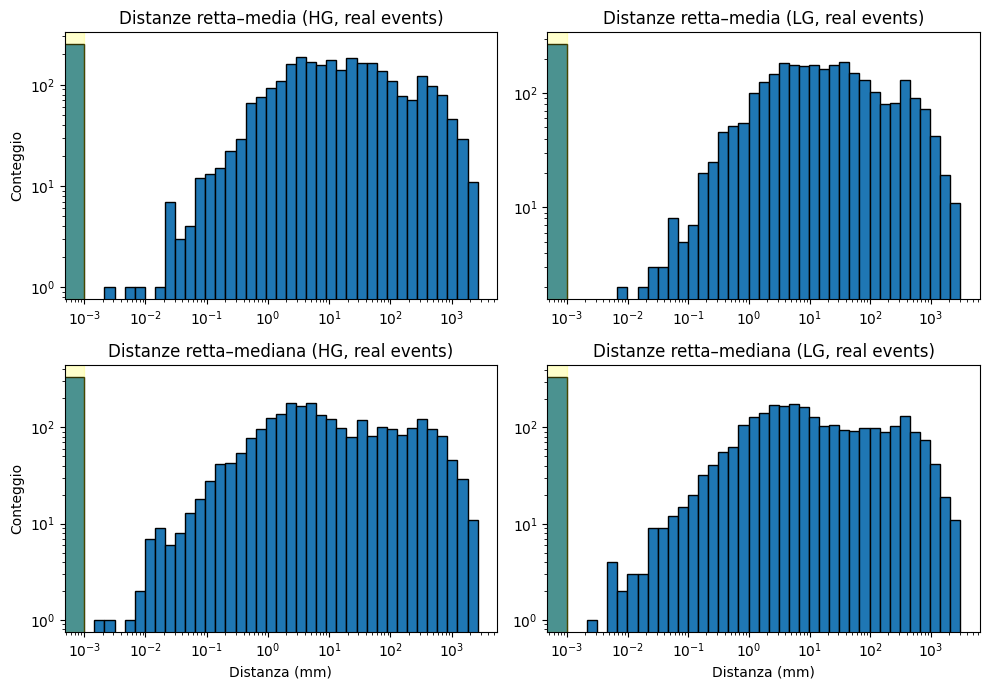

Index(['TIME_NS', 'TIME_S', 'TIME_ABS', 'EVENT', 'MCRUN', 'TEL_ID', 'num_tel',
       'HG', 'LG', 'TTP', 'shape', 'n_valid_pixels', 'time_group', 'P_median',
       'P_weight', 'P_simple'],
      dtype='object')


In [51]:
# ===================== ESTRAZIONE DISTANZE =====================
d_mean_hg   = df_dist_hg["d_weight"].values
d_median_hg = df_dist_hg["d_median"].values
d_mean_lg  = df_dist_lg["d_weight"].values
d_median_lg = df_dist_lg["d_median"].values

# filtro valori validi (>0 e finiti)
d_mean_hg   = d_mean_hg[np.isfinite(d_mean_hg) & (d_mean_hg > 0)]
d_median_hg = d_median_hg[np.isfinite(d_median_hg) & (d_median_hg > 0)]
d_mean_lg   = d_mean_lg[np.isfinite(d_mean_lg) & (d_mean_lg > 0)]
d_median_lg = d_median_lg[np.isfinite(d_median_lg) & (d_median_lg > 0)]

# -------------------- BINS LOGARITMICI SEPARATI --------------------
def smart_bins(data, n_bins=40, zero_threshold=0.001):
    """Crea bins logaritmici + bin speciale per valori ~0"""
    bin_zero = [0, zero_threshold]
    log_bins = np.logspace(np.log10(zero_threshold), np.log10(data.max()*1.1), n_bins)
    return np.unique(np.concatenate([bin_zero, log_bins]))

bins_mean_hg   = smart_bins(d_mean_hg)
bins_median_hg = smart_bins(d_median_hg)
bins_mean_lg   = smart_bins(d_mean_lg)
bins_median_lg = smart_bins(d_median_lg)

# ===================== PLOT =====================
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=False, sharey=False)

# -------------------- HG --------------------
axes[0,0].hist(d_mean_hg, bins=bins_mean_hg, edgecolor='black')
axes[0,0].set_title("Distanze retta–media (HG, real events)")
axes[0,0].set_ylabel("Conteggio")

axes[1,0].hist(d_median_hg, bins=bins_median_hg, edgecolor='black')
axes[1,0].set_title("Distanze retta–mediana (HG, real events)")
axes[1,0].set_ylabel("Conteggio")
axes[1,0].set_xlabel("Distanza (mm)")

# -------------------- LG --------------------
axes[0,1].hist(d_mean_lg, bins=bins_mean_lg, edgecolor='black')
axes[0,1].set_title("Distanze retta–media (LG, real events)")

axes[1,1].hist(d_median_lg, bins=bins_median_lg, edgecolor='black')
axes[1,1].set_title("Distanze retta–mediana (LG, real events)")
axes[1,1].set_xlabel("Distanza (mm)")

# scala log su entrambi gli assi
for ax in axes.flat:
    ax.axvspan(0, 0.001, alpha=0.2, color='yellow')
    ax.set_xscale("log")
    ax.set_yscale("log")

plt.tight_layout()
plt.show()
print(df_linked_events.columns)

In [52]:
# ======================= ASSEGNAZIONE CLUSTER PER HG =======================

def assign_clusters(df_dist, threshold=60):
    """
    Assegna ogni retta al cluster più vicino se distanza <= threshold.
    Altrimenti marca come non assegnata.
    """
    results = []
    
    # Raggruppa per (time_group, ogni combinazione è una retta unica######################################
    for (tg, tel), group in df_dist.groupby(['time_group', 'tel']):
        
        # Trova il cluster con distanza minima
        idx_min = group['d_median'].idxmin()
        min_dist = group.loc[idx_min, 'd_median']
        best_cluster = group.loc[idx_min, 'cluster']
        
        # Prendi le altre info (event, mcrun sono uguali per questa retta)
        event = group.loc[idx_min, 'event']
        mcrun = group.loc[idx_min, 'mcrun']
        P_median = group.loc[idx_min, 'P_median']
        
        # Assegna o marca come non assegnata
        if min_dist <= threshold:
            assigned_cluster = best_cluster
            is_assigned = True
        else:
            assigned_cluster = -1  # -1 indica "non assegnato"
            is_assigned = False
        if isinstance(event, np.ndarray):
            event = int(event[0]) if len(event) > 0 else -1
        else:
            event = int(event)
            
        if isinstance(mcrun, np.ndarray):
            mcrun = int(mcrun[0]) if len(mcrun) > 0 else -1
        else:
            mcrun = int(mcrun)
        results.append({
           
            'time_group': int(tg),
            'tel': int(tel),
            'event': int(event) if event is not None else -1,
            'mcrun': int(mcrun) if mcrun is not None else -1,
            'assigned_cluster': assigned_cluster,
            'is_assigned': is_assigned,
            'min_distance': min_dist,
            'n_clusters_available': len(group)  # quanti cluster erano disponibili
        })
    
    return pd.DataFrame(results)

# Applica l'assegnazione
df_assigned_hg = assign_clusters(df_dist_hg, threshold=60)
df_assigned_lg = assign_clusters(df_dist_lg, threshold=60)

# ======================= STATISTICHE =======================

print("="*70)
print("HG - Statistiche assegnazione")
print("="*70)
print(f"Rette totali: {len(df_assigned_hg)}")
print(f"Rette assegnate: {df_assigned_hg['is_assigned'].sum()}")
print(f"Rette non assegnate: {(~df_assigned_hg['is_assigned']).sum()}")
print(f"Percentuale assegnate: {100*df_assigned_hg['is_assigned'].mean():.1f}%")
print(f"\nDistribuzione cluster assegnati:")
print(df_assigned_hg[df_assigned_hg['is_assigned']]['assigned_cluster'].value_counts().sort_index())

print("\n" + "="*70)
print("LG - Statistiche assegnazione")
print("="*70)
print(f"Rette totali: {len(df_assigned_lg)}")
print(f"Rette assegnate: {df_assigned_lg['is_assigned'].sum()}")
print(f"Rette non assegnate: {(~df_assigned_lg['is_assigned']).sum()}")
print(f"Percentuale assegnate: {100*df_assigned_lg['is_assigned'].mean():.1f}%")
print(f"\nDistribuzione cluster assegnati:")
print(df_assigned_lg[df_assigned_lg['is_assigned']]['assigned_cluster'].value_counts().sort_index())


HG - Statistiche assegnazione
Rette totali: 2227
Rette assegnate: 2093
Rette non assegnate: 134
Percentuale assegnate: 94.0%

Distribuzione cluster assegnati:
assigned_cluster
0    1835
1     188
2      50
3      16
4       1
5       3
Name: count, dtype: int64

LG - Statistiche assegnazione
Rette totali: 2227
Rette assegnate: 2091
Rette non assegnate: 136
Percentuale assegnate: 93.9%

Distribuzione cluster assegnati:
assigned_cluster
0    1823
1     190
2      58
3      18
5       2
Name: count, dtype: int64


In [53]:
def evaluate_reconstruction(df_assigned):
    """
    Valuta la qualità della ricostruzione eventi confrontando con Monte Carlo.
    """
    # Conta eventi unici totali una sola volta
    eventi_unici_totali = df_assigned[['event', 'mcrun']].drop_duplicates()
    n_eventi_unici_totali = len(eventi_unici_totali)
    
    results = {
        'time_groups_totali': 0,
        'eventi_totali': n_eventi_unici_totali,  # Conta una sola volta
        'eventi_riconosciuti': 0,
        'eventi_ricostruiti_bene': 0,
        'dettagli': []
    }
    
    # Set per tracciare quali eventi sono stati riconosciuti/ricostruiti bene
    eventi_riconosciuti_set = set()
    eventi_ricostruiti_bene_set = set()
    
    time_groups = df_assigned['time_group'].unique()
    
    for time_group in time_groups:
        group = df_assigned[df_assigned['time_group'] == time_group]
        
        # Eventi veri
        eventi_veri_set = set((row['event'], row['mcrun']) for _, row in group.iterrows())
        n_eventi_veri = len(eventi_veri_set)
        eventi_veri_list = list(eventi_veri_set)
        
        # Cluster trovati
        cluster_trovati = group[group['is_assigned']]['assigned_cluster'].unique()
        n_cluster_trovati = len(cluster_trovati)
        
        results['time_groups_totali'] += 1
        
        # ===== RICONOSCIMENTO =====
        eventi_riconosciuti_correttamente = (n_cluster_trovati == n_eventi_veri)
        if eventi_riconosciuti_correttamente:
            eventi_riconosciuti_set.update(eventi_veri_set)
        
        # ===== PUREZZA CLUSTER =====
        cluster_puri = 0
        cluster_info = []
        
        for cluster_id in cluster_trovati:
            rette_cluster = group[group['assigned_cluster'] == cluster_id]
            eventi_nel_cluster_set = set((row['event'], row['mcrun']) for _, row in rette_cluster.iterrows())
            n_eventi_nel_cluster = len(eventi_nel_cluster_set)
            is_pure = (n_eventi_nel_cluster == 1)
            if is_pure:
                cluster_puri += 1
            
            cluster_info.append({
                'cluster': int(cluster_id),
                'n_rette': len(rette_cluster),
                'n_eventi_diversi': n_eventi_nel_cluster,
                'eventi': list(eventi_nel_cluster_set),
                'is_pure': is_pure
            })
        
        # ===== RETTE NON ASSEGNATE =====
        rette_non_assegnate = group[~group['is_assigned']]
        if len(rette_non_assegnate) > 0:
            eventi_non_assegnati_set = set((row['event'], row['mcrun']) for _, row in rette_non_assegnate.iterrows())
            n_eventi_non_assegnati = len(eventi_non_assegnati_set)
            is_pure_na = (n_eventi_non_assegnati == 1)
            if is_pure_na:
                cluster_puri += 1
            
            cluster_info.append({
                'cluster': -1,
                'n_rette': len(rette_non_assegnate),
                'n_eventi_diversi': n_eventi_non_assegnati,
                'eventi': list(eventi_non_assegnati_set),
                'is_pure': is_pure_na
            })
        
        # ===== RICOSTRUZIONE BENE =====
        tutti_cluster_puri = (cluster_puri == len(cluster_info))
        ricostruito_bene = tutti_cluster_puri and eventi_riconosciuti_correttamente
        
        if ricostruito_bene:
            eventi_ricostruiti_bene_set.update(eventi_veri_set)
        
        results['dettagli'].append({
            'time_group': int(time_group),
            'n_eventi_veri': n_eventi_veri,
            'eventi_veri': eventi_veri_list,
            'n_cluster_trovati': n_cluster_trovati,
            'eventi_riconosciuti_ok': eventi_riconosciuti_correttamente,
            'cluster_puri': cluster_puri,
            'totale_cluster': len(cluster_info),
            'tutti_cluster_puri': tutti_cluster_puri,
            'ricostruito_bene': ricostruito_bene,
            'cluster_info': cluster_info
        })
    
    # Aggiorna i contatori finali
    results['eventi_riconosciuti'] = len(eventi_riconosciuti_set)
    results['eventi_ricostruiti_bene'] = len(eventi_ricostruiti_bene_set)
    
    return results

# ======================= APPLICA VALUTAZIONE =======================

print("="*70)
print("VALUTAZIONE HG")
print("="*70)
eval_hg = evaluate_reconstruction(df_assigned_hg)

print(f"\nTime groups analizzati: {eval_hg['time_groups_totali']}")
print(f"Eventi totali (veri): {eval_hg['eventi_totali']}")
print(f"\nEventi RICONOSCIUTI (numero cluster = numero eventi): {eval_hg['eventi_riconosciuti']}")
print(f"  → Efficienza riconoscimento: {100*eval_hg['eventi_riconosciuti']*2/eval_hg['eventi_totali']:.1f}%")
print(f"\nEventi RICOSTRUITI BENE (cluster puri + numero corretto): {eval_hg['eventi_ricostruiti_bene']}")
print(f"  → Efficienza ricostruzione: {100*eval_hg['eventi_ricostruiti_bene']*2/eval_hg['eventi_totali']:.1f}%")

print("\n" + "="*70)
print("VALUTAZIONE LG")
print("="*70)
eval_lg = evaluate_reconstruction(df_assigned_lg)

print(f"\nTime groups analizzati: {eval_lg['time_groups_totali']}")
print(f"Eventi totali (veri): {eval_lg['eventi_totali']}")
print(f"\nEventi RICONOSCIUTI (numero cluster = numero eventi): {eval_lg['eventi_riconosciuti']}")
print(f"  → Efficienza riconoscimento: {100*eval_lg['eventi_riconosciuti']/eval_lg['eventi_totali']:.1f}%")
print(f"\nEventi RICOSTRUITI BENE (cluster puri + numero corretto): {eval_lg['eventi_ricostruiti_bene']}")
print(f"  → Efficienza ricostruzione: {100*eval_lg['eventi_ricostruiti_bene']/eval_lg['eventi_totali']:.1f}%")

# ======================= ESEMPI DETTAGLIATI =======================

print("\n" + "="*70)
print("ESEMPI DI TIME GROUPS (HG):")
print("="*70)

for detail in eval_hg['dettagli'][:5]:  # Primi 5 esempi
    print(f"\nTime Group {detail['time_group']}:")
    print(f"  Eventi veri: {detail['eventi_veri']}")
    print(f"  Cluster trovati: {detail['n_cluster_trovati']}")
    print(f"  Riconosciuto: {detail['eventi_riconosciuti_ok']}")
    print(f"  Ricostruito bene: {detail['ricostruito_bene']}")
    print(f"  Dettaglio cluster:")
    for ci in detail['cluster_info']:
        purity = " PURO" if ci['is_pure'] else " MISTO"
        print(f"    Cluster {ci['cluster']}: {ci['n_rette']} rette, {ci['n_eventi_diversi']} eventi {purity}")
        print(f"      Eventi: {ci['eventi']}")
# MERGE: Aggiungi informazioni di clustering a df_linked_events
# ===================================================================


# df_assigned_hg ha: time_group, tel, EVENT, mcrun, assigned_cluster, is_assigned, min_distance, n_clusters_available
# df_linked_events ha: time_group, TEL_ID, EVENT, MCRUN, HG, LG, TTP, shape, ecc.

df_merged = pd.merge(
    df_linked_events, 
    df_assigned_hg,
    left_on=['TEL_ID', 'time_group', 'EVENT', 'MCRUN'],
    right_on=['tel', 'time_group', 'event', 'mcrun'],
    how='inner'  # o 'left', 'right', 'outer' a seconda delle tue esigenze
)

# Rimuovi le colonne duplicate dal secondo dataframe
df_merged = df_merged.drop(columns=['tel', 'event', 'mcrun'])

###################################################################################
# PRIMA del merge
print("Prima del merge:")
print(df_linked_events[['time_group', 'P_median']].head(20))
print(f"NaN in P_median: {df_linked_events['P_median'].isna().sum()}")

# DOPO il merge

print("\nDopo il merge:")
print(df_merged[['time_group', 'P_median']].head(20))
print(f"NaN in P_median: {df_merged['P_median'].isna().sum()}")

VALUTAZIONE HG

Time groups analizzati: 447
Eventi totali (veri): 894

Eventi RICONOSCIUTI (numero cluster = numero eventi): 158
  → Efficienza riconoscimento: 35.3%

Eventi RICOSTRUITI BENE (cluster puri + numero corretto): 46
  → Efficienza ricostruzione: 10.3%

VALUTAZIONE LG

Time groups analizzati: 447
Eventi totali (veri): 894

Eventi RICONOSCIUTI (numero cluster = numero eventi): 162
  → Efficienza riconoscimento: 18.1%

Eventi RICOSTRUITI BENE (cluster puri + numero corretto): 48
  → Efficienza ricostruzione: 5.4%

ESEMPI DI TIME GROUPS (HG):

Time Group 1:
  Eventi veri: [(3007, 220000), (1007, 220000)]
  Cluster trovati: 1
  Riconosciuto: False
  Ricostruito bene: False
  Dettaglio cluster:
    Cluster 0: 4 rette, 1 eventi  PURO
      Eventi: [(1007, 220000)]
    Cluster -1: 1 rette, 1 eventi  PURO
      Eventi: [(3007, 220000)]

Time Group 4:
  Eventi veri: [(15908, 220000), (10109, 220000)]
  Cluster trovati: 2
  Riconosciuto: True
  Ricostruito bene: True
  Dettaglio clust


TIME GROUP 1
Telescopi: 5 | Eventi MC: [1007 3007] | MCRUN: [220000]


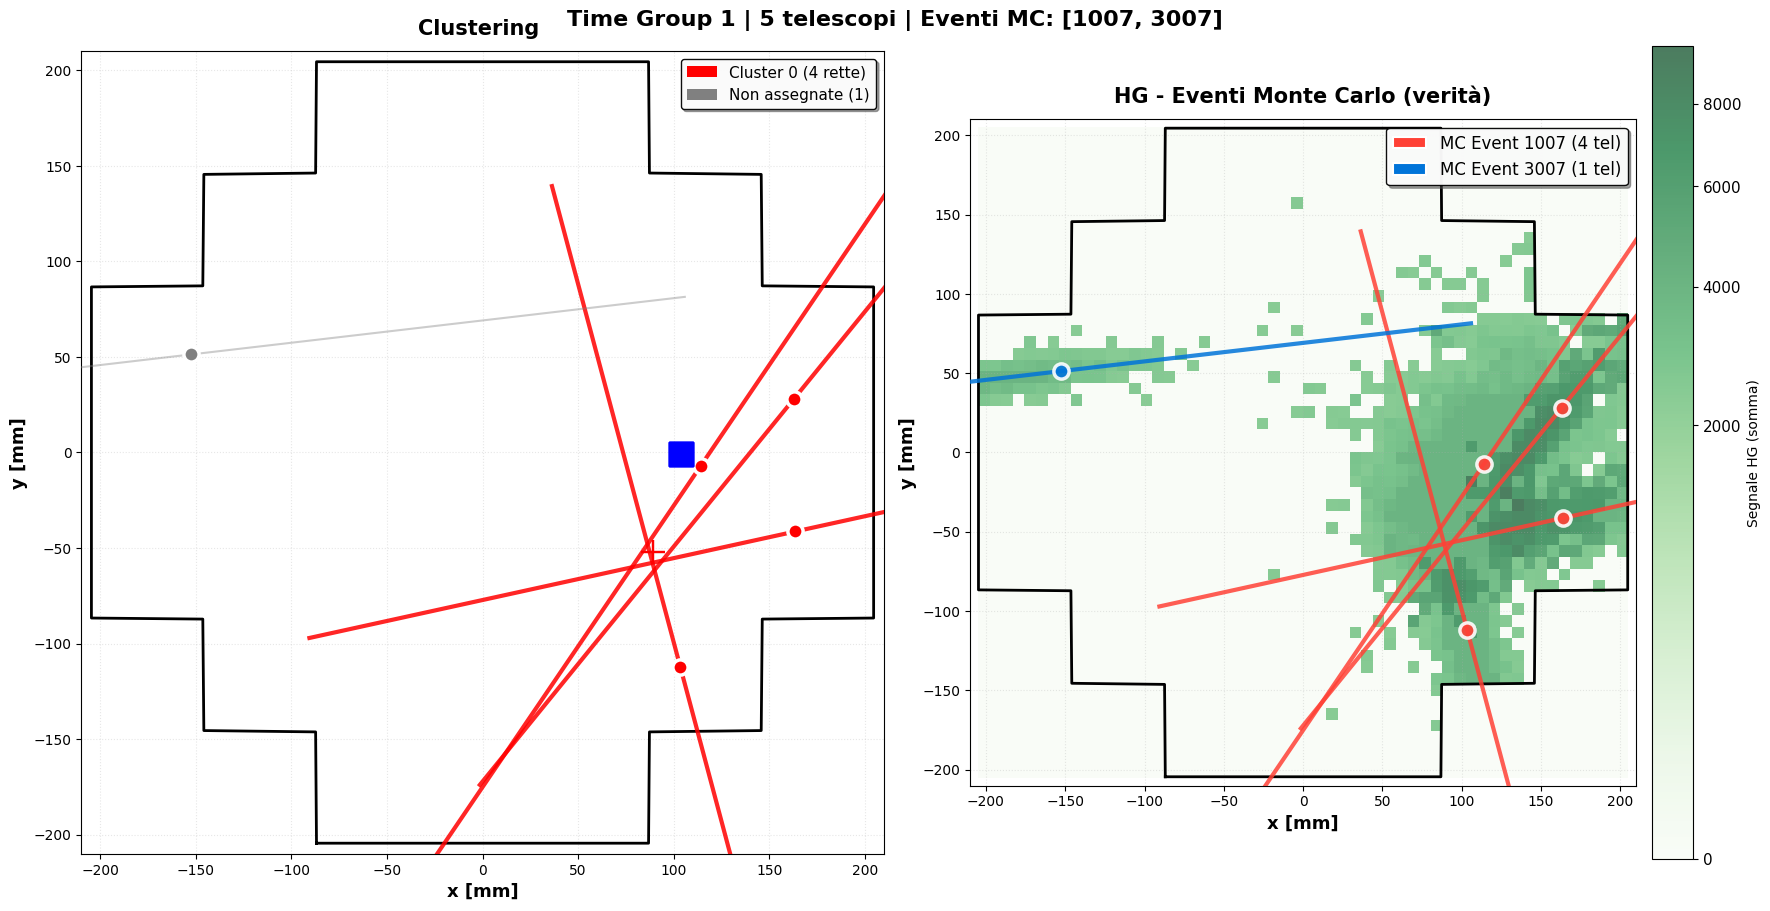

✓ Completato time_group 1
  Rette per evento MC: {1007: 4, 3007: 1}
  Cluster trovati: [0]
  Rette per cluster: {0: 4, -1: 1}


TIME GROUP 4
Telescopi: 12 | Eventi MC: [10109 15908] | MCRUN: [220000]


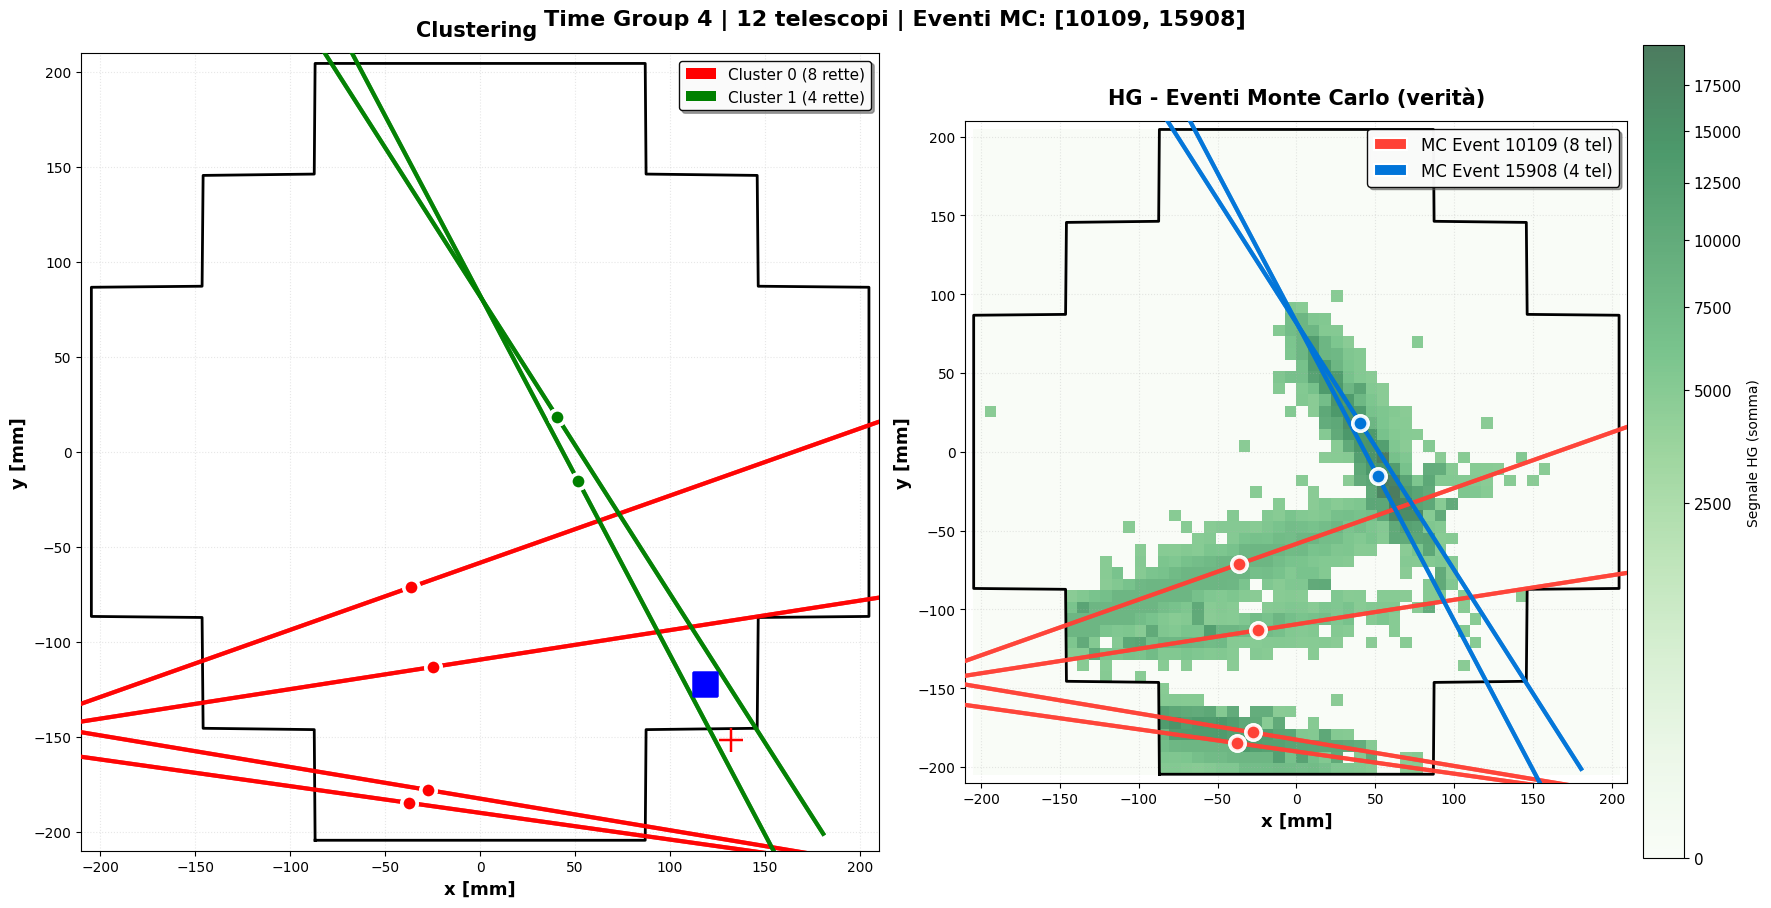

✓ Completato time_group 4
  Rette per evento MC: {10109: 8, 15908: 4}
  Cluster trovati: [0, 1]
  Rette per cluster: {0: 8, 1: 4, -1: 0}



In [54]:
# Lunghezza rette
xfp, yfp = at.utils.camera.get_xy_footprint()
y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T
x_pix = at.reshape(x_pix)
y_pix = at.reshape(y_pix)

xmin, xmax = np.min(xfp), np.max(xfp)
ymin, ymax = np.min(yfp), np.max(yfp)
diag = np.sqrt((xmax - xmin)**2 + (ymax - ymin)**2)
L = 0.45 * diag

for time_group in df_merged['time_group'][:10].drop_duplicates().values[:]:
    
    # ===================================================================
    # PREPARAZIONE DATI
    # ===================================================================
    
    # Estrai tutti i telescopi di questo gruppo temporale
    df_window = df_merged[df_merged['time_group'] == time_group].copy()
    
    # Informazioni sul gruppo
    unique_events = df_window['EVENT'].unique()
    unique_mcruns = df_window['MCRUN'].unique()
    
    print(f"\n{'='*70}")
    print(f"TIME GROUP {time_group}")
    print(f"Telescopi: {len(df_window)} | Eventi MC: {unique_events} | MCRUN: {unique_mcruns}")
    print(f"{'='*70}")
    
    # ===================================================================
    # PLOT SIDE-BY-SIDE
    # ===================================================================
    
    fig, ax = plt.subplots(1, 2, figsize=(18, 9))
    
    # Colori per cluster assegnati (il tuo metodo)
    cluster_trovati = df_window[df_window['is_assigned']]['assigned_cluster'].unique()
    colori_cluster = {cluster_trovati[i]: ['red', 'green', 'blue', 'orange', 'cyan'][i % 5] 
                     for i in range(len(cluster_trovati))}
    colori_cluster[-1] = 'gray'  # outliers
    
    # Colori per eventi MC
    colors_mc = ['#FF4136', '#0074D9', '#2ECC40', '#FF851B']
    event_color_map = {unique_events[i]: colors_mc[i % len(colors_mc)] for i in range(len(unique_events))}
    
    # Contatori
    rette_per_cluster = {c: 0 for c in cluster_trovati}
    rette_per_cluster[-1] = 0  # outliers
    rette_per_evento = {ev: 0 for ev in unique_events}
    
    # Inizializza array per heatmap
    weights_hg = np.zeros((37, 64))
    mask_tot = np.zeros((37, 64), dtype=bool)
    
    # ─── SINISTRA: CLUSTERING ─────────────────────────────────────────
    for idx, row in df_window.iterrows():
        
        hgev = np.array(row['HG'])
        ttpev = np.array(row['TTP'])
        pxmask = (hgev > 2400) & (ttpev < 255)
        
        if not np.any(pxmask):
            continue
        
        # ===== SIGMA-CLIPPING =====
        xx = x_pix[pxmask].flatten()
        yy = y_pix[pxmask].flatten()
        w_hg = hgev[pxmask].flatten()
        
        # Centroide iniziale
        mx0 = np.average(xx, weights=w_hg)
        my0 = np.average(yy, weights=w_hg)
        
        # Sigma-clipping
        r = np.sqrt((xx - mx0)**2 + (yy - my0)**2)
        r_clip, low, high = sc.sigmaclip(r, low=2., high=2.)
        keep = (r >= low) & (r <= high)
        
        xx_sc = xx[keep]
        yy_sc = yy[keep]
        w_hg_sc = w_hg[keep]
        # ==========================
        
        if len(xx_sc) < 2:
            continue
        
        # Centroide pesato sui dati clippati
        meanx_hg = np.average(xx_sc, weights=w_hg_sc)
        meany_hg = np.average(yy_sc, weights=w_hg_sc)
        
        # Covarianza per direzione sui dati clippati
        cov_hg = np.cov([xx_sc, yy_sc], aweights=w_hg_sc)
        l1_hg = (cov_hg[0,0] + cov_hg[1,1])/2 + np.sqrt(((cov_hg[0,0] - cov_hg[1,1])/2)**2 + cov_hg[0,1]**2)
        theta_hg = np.arctan2(l1_hg - cov_hg[0,0], cov_hg[0,1])
        
        # Recupera centri mediana e media pesata
        centro0 = np.array(row['P_median'])
        centro1 = np.array(row['P_weight'])
        
        # Cluster assegnato
        if row['is_assigned']:
            cluster_id = row['assigned_cluster']
            col = colori_cluster.get(cluster_id, 'purple')
            alpha = 0.85
            lw = 3.0
            rette_per_cluster[cluster_id] += 1
        else:
            col = 'gray'
            alpha = 0.4
            lw = 1.5
            rette_per_cluster[-1] += 1
        
        # Disegna retta
        x1 = meanx_hg - L * np.cos(theta_hg)
        y1 = meany_hg - L * np.sin(theta_hg)
        x2 = meanx_hg + L * np.cos(theta_hg)
        y2 = meany_hg + L * np.sin(theta_hg)
        
        ax[0].plot([x1, x2], [y1, y2], color=col, linewidth=lw, alpha=alpha, zorder=5)
        ax[0].scatter(meanx_hg, meany_hg, s=120, color=col, edgecolor='white', linewidth=2.5, zorder=6)
    
    # Disegna centri mediana e media pesata (FUORI dal loop per evitare duplicati)
    for idx, row in df_window.iterrows():
        centro0 = np.array(row['P_median'])
        centro1 = np.array(row['P_weight'])
        
        if centro0.ndim == 1:
            # È un singolo punto
            ax[0].scatter(centro0[0], centro0[1], marker='+', s=320, c='red', zorder=6)
            ax[0].scatter(centro1[0], centro1[1], marker='s', s=320, c='blue', zorder=6)
        elif centro0.ndim == 2:
            # Sono multipli punti
            ax[0].scatter(centro0[:, 0], centro0[:, 1], marker='+', s=320, c='red', zorder=6)
            ax[0].scatter(centro1[:, 0], centro1[:, 1], marker='s', s=320, c='blue', zorder=6)
    
    # Disegna centri cluster (se presenti in df_window)
    for cluster_id in cluster_trovati:
        cluster_rows = df_window[df_window['assigned_cluster'] == cluster_id]
        if len(cluster_rows) > 0 and 'center_x' in cluster_rows.columns:
            center_x = cluster_rows['center_x'].iloc[0]
            center_y = cluster_rows['center_y'].iloc[0]
            ax[0].scatter(center_x, center_y, marker='X', s=500, 
                        c=colori_cluster.get(cluster_id, 'black'), linewidth=4, zorder=7,
                        edgecolor='white')
    
    ax[0].plot(xfp, yfp, 'k-', linewidth=2, zorder=2)
    ax[0].set_title(f'Clustering ', fontweight='bold', fontsize=15, pad=12)
    ax[0].set_xlim(-210, 210)
    ax[0].set_ylim(-210, 210)
    ax[0].set_aspect('equal')
    ax[0].set_xlabel('x [mm]', fontsize=13, fontweight='bold')
    ax[0].set_ylabel('y [mm]', fontsize=13, fontweight='bold')
    ax[0].grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
    
    # Legenda clustering
    legend_clustering = []
    for c in cluster_trovati:
        if rette_per_cluster[c] > 0:
            legend_clustering.append(Patch(facecolor=colori_cluster[c], 
                                          label=f'Cluster {c} ({rette_per_cluster[c]} rette)'))
    if rette_per_cluster[-1] > 0:
        legend_clustering.append(Patch(facecolor='gray', 
                                      label=f'Non assegnate ({rette_per_cluster[-1]})'))
    ax[0].legend(handles=legend_clustering, loc='upper right', fontsize=11, 
                framealpha=0.95, edgecolor='black', fancybox=True, shadow=True)
    
    # ─── DESTRA: HG CON EVENTI MC ─────────────────────────────────────
    for idx, row in df_window.iterrows():
        
        hgev = np.array(row['HG'])
        ttpev = np.array(row['TTP'])
        pxmask = (hgev > 2400) & (ttpev < 255)
        
        if not np.any(pxmask):
            continue
        
        # ===== SIGMA-CLIPPING =====
        xx = x_pix[pxmask].flatten()
        yy = y_pix[pxmask].flatten()
        w_hg = hgev[pxmask].flatten()
        
        # Centroide iniziale
        mx0 = np.average(xx, weights=w_hg)
        my0 = np.average(yy, weights=w_hg)
        
        # Sigma-clipping
        r = np.sqrt((xx - mx0)**2 + (yy - my0)**2)
        r_clip, low, high = sc.sigmaclip(r, low=2., high=2.)
        keep = (r >= low) & (r <= high)
        
        xx_sc = xx[keep]
        yy_sc = yy[keep]
        w_hg_sc = w_hg[keep]
        # ==========================
        
        if len(xx_sc) < 2:
            continue
        
        # Somma per heatmap (usa TUTTI i pixel, non quelli clippati)
        weights_hg[pxmask] += hgev[pxmask]
        mask_tot |= pxmask
        
        # Centroide sui dati clippati
        meanx_hg = np.average(xx_sc, weights=w_hg_sc)
        meany_hg = np.average(yy_sc, weights=w_hg_sc)
        
        # Covarianza sui dati clippati
        cov_hg = np.cov([xx_sc, yy_sc], aweights=w_hg_sc)
        l1_hg = (cov_hg[0,0] + cov_hg[1,1])/2 + np.sqrt(((cov_hg[0,0] - cov_hg[1,1])/2)**2 + cov_hg[0,1]**2)
        theta_hg = np.arctan2(l1_hg - cov_hg[0,0], cov_hg[0,1])
        
        color_ev = event_color_map[row['EVENT']]
        rette_per_evento[row['EVENT']] += 1
        
        ax[1].scatter(meanx_hg, meany_hg, s=120, color=color_ev, 
                     edgecolor='white', linewidth=2.5, zorder=6, alpha=0.9)
        
        x1 = meanx_hg - L * np.cos(theta_hg)
        y1 = meany_hg - L * np.sin(theta_hg)
        x2 = meanx_hg + L * np.cos(theta_hg)
        y2 = meany_hg + L * np.sin(theta_hg)
        ax[1].plot([x1, x2], [y1, y2], color=color_ev, linewidth=3, alpha=0.85, zorder=5)
    
    # Heatmap
    h1 = ax[1].hist2d(x_pix[mask_tot].flatten(), y_pix[mask_tot].flatten(),
                     weights=weights_hg[mask_tot].flatten(), 
                     range=((-205, 205), (-205, 205)),
                     bins=7*8, cmap='Greens', alpha=0.7, norm=PowerNorm(0.4))
    
    ax[1].plot(xfp, yfp, 'k-', linewidth=2, zorder=2)
    ax[1].set_xlim(-210, 210)
    ax[1].set_ylim(-210, 210)
    ax[1].set_aspect('equal')
    ax[1].set_xlabel('x [mm]', fontsize=13, fontweight='bold')
    ax[1].set_ylabel('y [mm]', fontsize=13, fontweight='bold')
    ax[1].grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
    ax[1].set_title(f'HG - Eventi Monte Carlo (verità)', fontweight='bold', fontsize=15, pad=12)
    
    # Colorbar
    cbar1 = fig.colorbar(h1[3], ax=ax[1], label='Segnale HG (somma)', pad=0.02)
    cbar1.ax.tick_params(labelsize=11)
    
    # Legenda eventi MC
    legend_mc = [
        Patch(facecolor=event_color_map[ev], edgecolor='white', linewidth=1.5,
              label=f'MC Event {ev} ({rette_per_evento[ev]} tel)')
        for ev in unique_events
    ]
    ax[1].legend(handles=legend_mc, loc='upper right', fontsize=12, 
                framealpha=0.95, edgecolor='black', fancybox=True, shadow=True)
    
    plt.suptitle(f'Time Group {time_group} | {len(df_window)} telescopi | Eventi MC: {list(unique_events)}',
                fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Completato time_group {time_group}")
    print(f"  Rette per evento MC: {rette_per_evento}")
    print(f"  Cluster trovati: {list(cluster_trovati)}")
    print(f"  Rette per cluster: {rette_per_cluster}\n")



ANALISI HEATMAP TIME GROUP 657

  Telescopi: 4
  Eventi MC: [10103, 10106]
  MCRUN: [220287]

 TEMPI
  TIME_ABS range: [2151556046, 2151638321]
  Delta temporale: 82275.00 ns
  TIME_S (primo): 2
  TIME_NS (primo): 151556046

TELESCOPI:
  Tel 1: Event 10103, MCRUN 220287, TIME_ABS=2151556046, pixels=83
  Tel 2: Event 10103, MCRUN 220287, TIME_ABS=2151556309, pixels=61
  Tel 4: Event 10106, MCRUN 220287, TIME_ABS=2151638307, pixels=102
  Tel 3: Event 10106, MCRUN 220287, TIME_ABS=2151638321, pixels=77


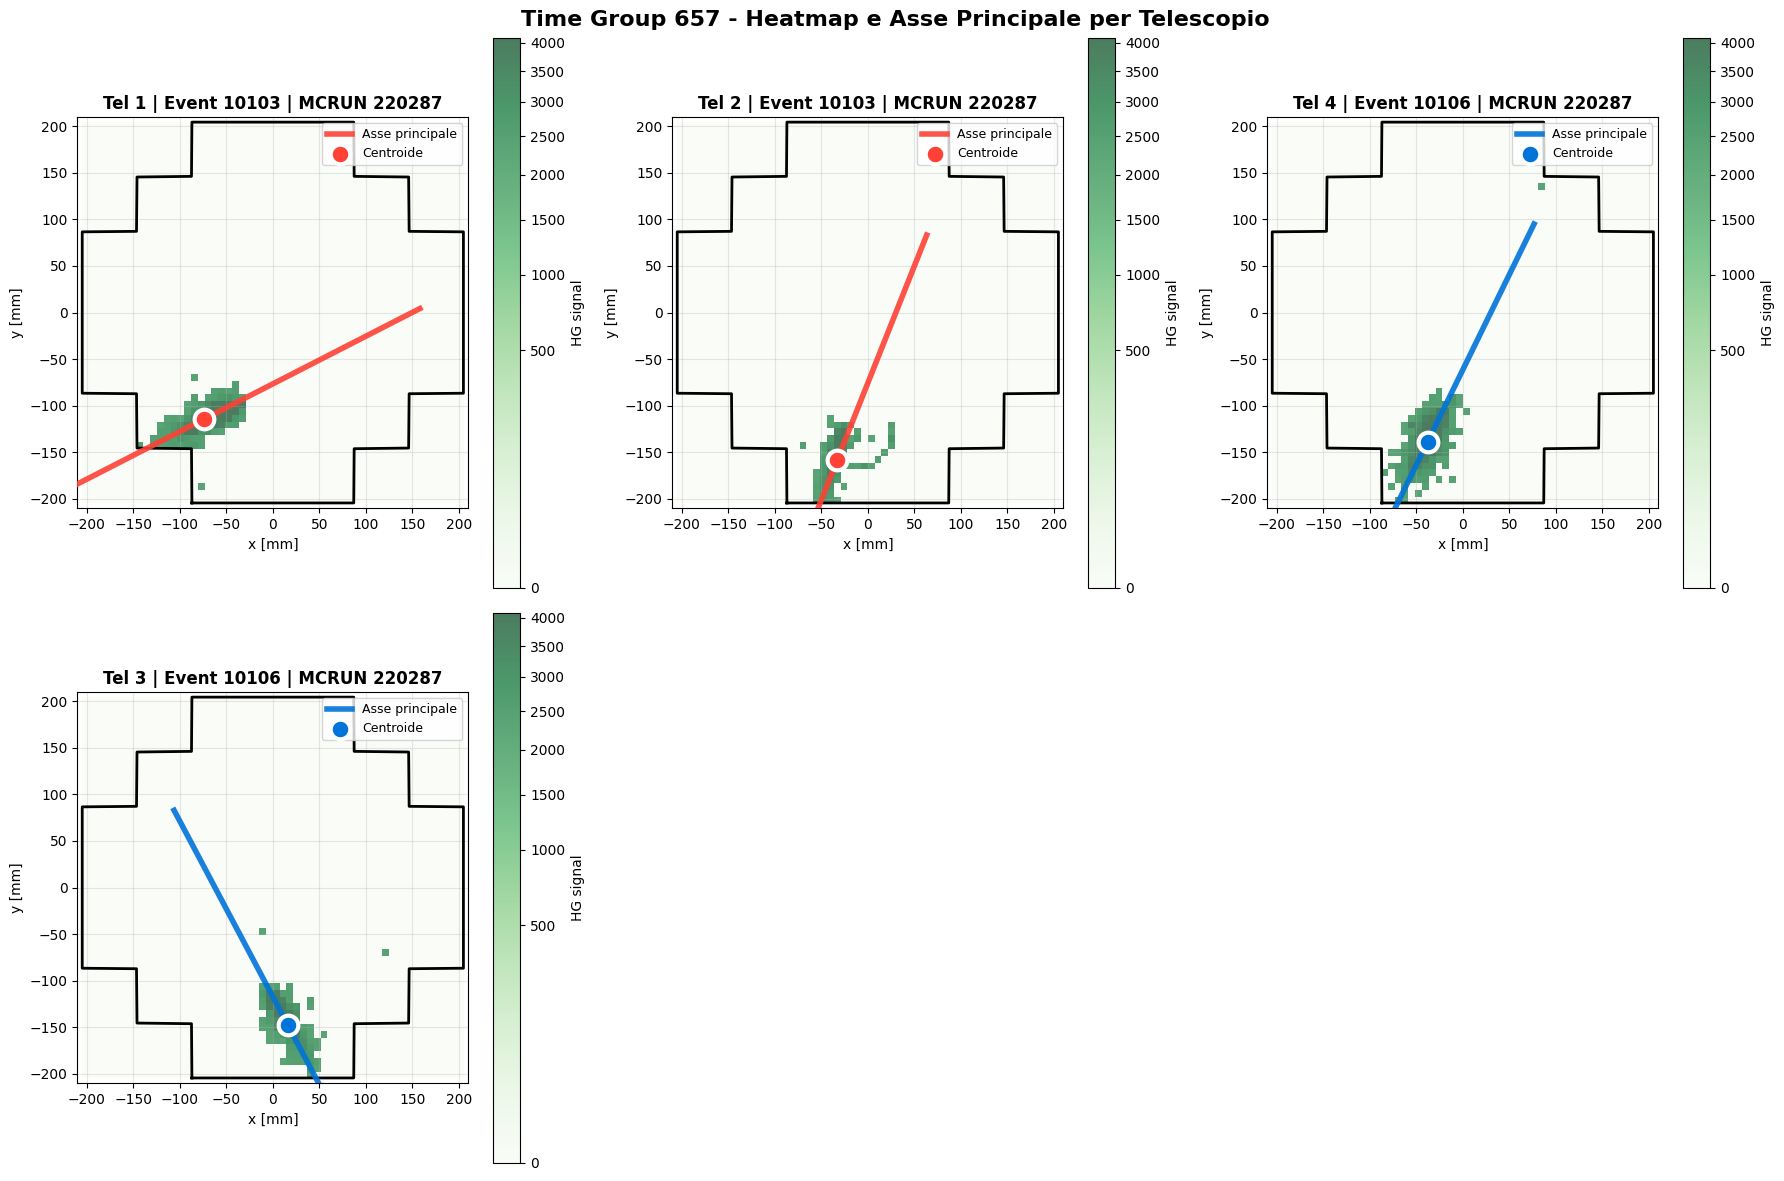

In [55]:
xfp, yfp = at.utils.camera.get_xy_footprint()
y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T
x_pix = at.reshape(x_pix)
y_pix = at.reshape(y_pix)

# Lunghezza rette
xmin, xmax = np.min(xfp), np.max(xfp)
ymin, ymax = np.min(yfp), np.max(yfp)
diag = np.sqrt((xmax - xmin)**2 + (ymax - ymin)**2)
L = 0.45 * diag
#657, 2699
def rette_time_group(time_group):
    """
    Mostra solo heatmap e asse principale per ogni telescopio di un time_group
    """
    
    print(f"\n{'='*80}")
    print(f"ANALISI HEATMAP TIME GROUP {time_group}")
    print(f"{'='*80}\n")
    
    # Estrai dati
    dfR_tg = dfR[dfR['time_group'] == time_group].copy()
    df_data_tg = df_linked_events[df_linked_events['time_group'] == time_group].copy()
    
    if len(dfR_tg) == 0:
        print(f" Nessuna retta per time_group {time_group}")
        return
    
    # Info generali
    unique_events = dfR_tg['event'].unique()
    unique_mcruns = dfR_tg['mcrun'].unique()
    n_telescopi = len(dfR_tg)
    
    
    print(f"  Telescopi: {n_telescopi}")
    print(f"  Eventi MC: {list(unique_events)}")
    print(f"  MCRUN: {list(unique_mcruns)}")
    
    # Informazioni temporali
    if len(df_data_tg) > 0:
        time_abs_vals = df_data_tg['TIME_ABS'].values
        time_s_vals = df_data_tg['TIME_S'].values
        time_ns_vals = df_data_tg['TIME_NS'].values
        
        print(f"\n TEMPI")
        print(f"  TIME_ABS range: [{time_abs_vals.min()}, {time_abs_vals.max()}]")
        print(f"  Delta temporale: {time_abs_vals.max() - time_abs_vals.min():.2f} ns")
        print(f"  TIME_S (primo): {time_s_vals[0]}")
        print(f"  TIME_NS (primo): {time_ns_vals[0]}")
    
    # Setup plot
    n_cols = 3
    n_rows = int(np.ceil(n_telescopi / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    # Colori per eventi
    colors_mc = ['#FF4136', '#0074D9', '#2ECC40', '#FF851B']
    event_color_map = {unique_events[i]: colors_mc[i % len(colors_mc)] for i in range(len(unique_events))}
    
    print(f"\nTELESCOPI:")
    
    for idx, (_, row_r) in enumerate(dfR_tg.iterrows()):
        tel_id = row_r["HG"]["tel"]
        event = row_r["event"]
        mcrun = row_r["mcrun"]
        p0 = row_r["HG"]["p0"]
        d = row_r["HG"]["d"]
        
        ax = axes[idx]
        
        # Trova dati pixel
        mask_tel = (df_data_tg['TEL_ID'] == tel_id)
        
        if mask_tel.sum() > 0:
            row_data = df_data_tg[mask_tel].iloc[0]
            hgev = np.array(row_data['HG'])
            ttpev = np.array(row_data['TTP'])
            time_abs = row_data['TIME_ABS']
            
            pxmask = (hgev > 2400) & (ttpev < 255)
            
            print(f"  Tel {tel_id}: Event {event}, MCRUN {mcrun}, TIME_ABS={time_abs}, pixels={np.sum(pxmask)}")
            
            if np.any(pxmask):
                # Heatmap
                h = ax.hist2d(x_pix[pxmask].flatten(), y_pix[pxmask].flatten(),
                             weights=hgev[pxmask].flatten(), 
                             range=((-205, 205), (-205, 205)),
                             bins=7*8, cmap='Greens', alpha=0.7, norm=PowerNorm(0.4))
                
                # Asse principale (retta)
                theta = np.arctan2(d[1], d[0])
                x1 = p0[0] - L * np.cos(theta)
                y1 = p0[1] - L * np.sin(theta)
                x2 = p0[0] + L * np.cos(theta)
                y2 = p0[1] + L * np.sin(theta)
                
                ax.plot([x1, x2], [y1, y2], color=event_color_map[event], 
                       linewidth=4, alpha=0.9, zorder=5, label='Asse principale')
                ax.scatter(p0[0], p0[1], s=200, color=event_color_map[event], 
                          edgecolor='white', linewidth=3, zorder=6, label='Centroide')
                
                # Colorbar
                plt.colorbar(h[3], ax=ax, label='HG signal')
        
        # Footprint camera
        ax.plot(xfp, yfp, 'k-', linewidth=2)
        ax.set_xlim(-210, 210)
        ax.set_ylim(-210, 210)
        ax.set_aspect('equal')
        ax.set_title(f'Tel {tel_id} | Event {event} | MCRUN {mcrun}', 
                    fontsize=12, fontweight='bold')
        ax.set_xlabel('x [mm]', fontsize=10)
        ax.set_ylabel('y [mm]', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right', fontsize=9)
    
    # Rimuovi assi vuoti
    for idx in range(n_telescopi, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'Time Group {time_group} - Heatmap e Asse Principale per Telescopio', 
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
rette_time_group(657)